<a href="https://colab.research.google.com/github/2412tessa-gif/UM-MSP-BIGDATAINPHYSICS/blob/main/ML_cifar_CNN_finalversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

In [23]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


In [24]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


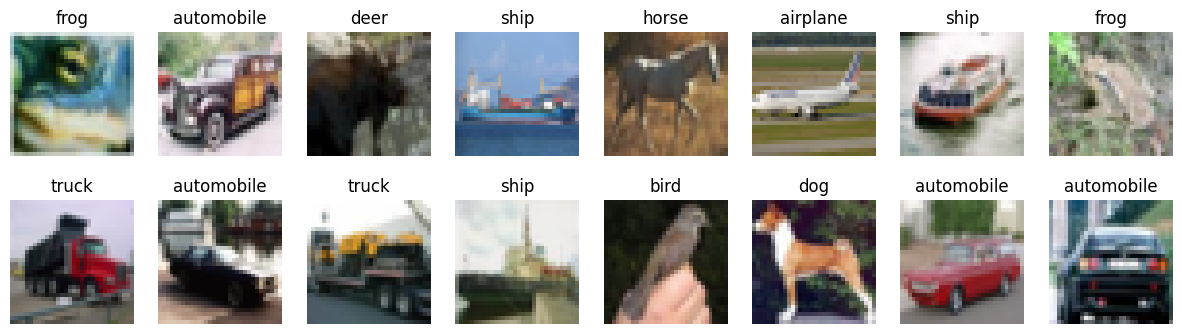

In [25]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [26]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [27]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout,
    LeakyReLU, BatchNormalization, GlobalAveragePooling2D
)
import tensorflow as tf


In [28]:
def make_model():
    model = Sequential()

    ### STUDENT CODE HERE ###

    # Model is structured in blocks of convolutional layers before pooling with two convolutions at the same resolution
    # Pooling is a common optimization technique used where information is 'pooled' (reduced spatial dimensionality) to increase computational speed.

    # Block 1
    # simple edges are combined into slightly more complex patterns before throwing away spatial info via pooling.
    model.add(Conv2D(64, (3, 3), padding='same', input_shape=(32, 32, 3)))

    model.add(BatchNormalization())
    # Normalizes Layers every mini-batch so the next layer always sees a stable input distribution -> used to minimize epochs

    model.add(Activation('relu'))
    # ReLU is default choice for activation function (it passes positive values through layers unchanged and outputs zero for negative values)

    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(MaxPooling2D(pool_size=(2, 2)))
    # Max-pool keeps the strongest activation in each 2x2 patch

    model.add(Dropout(0.2))
    # We set dropout light early on because we don't want to discard too many useful edge detectors in the beginning

    # Block 2
    # We increase filter count to 128 for deeper spatial hierarchy -> number of distinct mid-level textures is larger than the number of elementary edges.
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))

    # LeakyReLU used here to avoid dead neurons that ReLU could've created
    # slope 0.1 is a common safe default because it is small enough not to hurt positive side and large enough to keep gradient

    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.3))

    # mid-level features are more redundant now, so dropping 30% of the signal in the neurons still leaves enough signal in the following layers.

    # Block 3
    # We increase to 256 filters because the receptive field is now large enough to see most of an object, so we need more filters to capture the variety of high-level features (rotation, etc)
    model.add(Conv2D(256, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))

    model.add(Conv2D(256, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.3))

    # Block 4
    # We increase, again, to 512 filters. The spatial map is tiny now so we can afford many filters without the memory cost being huge (4x4x512 = 8192 values per image).
    # This block captures the most abstract, high-level features.
    model.add(Conv2D(512, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))  # 4x4 → 2x2
    model.add(Dropout(0.4))

    # Individual neurons are very specialised in this block and prone to overfitting specific training examples

    model.add(Flatten())
    # Flatten the layers from 2D into a 1D Vector  (2x2x512 = 2048 values → 1D vector)

    model.add(Dense(1024))
    # The first FC layer combines 2048 features across the whole image into 1024 for a 50% dropout (standard in FC layers as they have way more parameters);
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.5))


    model.add(Dense(512))
    # the second FC layer combines 1024 features into 512 to compress them into a more discriminative representation.
    model.add(BatchNormalization())
    model.add(Activation(lambda x: tf.keras.activations.tanh(x)))
    # tanh bounded in [-1, 1] means the final logit layer sees a nicely scaled input regardless of magnitude.
    # Intentionally mixing activation types (relu, leaky relu, tanh) also adds implicit diversity meaning each block learns slightly differently shaped decision boundaries.
    model.add(Dropout(0.5))

    model.add(Dense(NUM_CLASSES))

    ### END STUDENT CODE ###

    model.add(Activation("softmax"))
    return model

## Markdowns for the Code

**Why do we have 4 conv blocks with doubling filter counts (64,128,256,512)?**  
The filter count doubles at each block because the number of learnable visual concepts grows at each abstraction level. Block 1 deals with edges and colours (block 1), Block 2 deals with mid-level textures which are more varied. Blocks 3 and 4 deal with object parts with are the most numerous features.  That is also why I halved the spatial resolution with MaxPool at each stage to keep the total computation roughly constant at every block iteration.

**Why was padding the same throughout?**  
`same` padding preserves dimensions so pooling is the only thing controlling resolution, which is required for the Block Structure to work for this Model.

**Why did I use BatchNorm before the activation?**  
BatchNorm normalises the pre-activation values, so the activation function always operates in its most useful input range. Example: Relu already clips negatives, so normalising post-relu shifts the mean in a way BN then has to undo, which would be cumbersome.

**Why mix activation types?**  
**Block 2**: LeakyReLU targets the dead-neuron problem that appears at mid-depth when gradients are still large enough to drive units permanently negative.

**Block 1,3-4**: BatchNorm keeps activations stable enough that standard ReLU is fine.

**Block 5**: Tanh in the final FC layer provides a bounded pre-logit representation which is more numerically stable than an unbounded ReLU output feeding directly into the softmax.

Each Activation types has its pros and cons which are used appropriately here.

**Possible ways of improvements**  

- Regularisation

   A more gradual progression for Dropout (e.g. 0.25 → 0.35 → 0.5) using L2 weight regularisation on the Dense layers as an alternative or complement to dropout

- Training considerations (outside this function but relevant)

  Using a learning rate scheduler (e.g. cosine decay or ReduceLROnPlateau)
  and Data augmentation (flips, crops, colour jitter) on CIFAR-32 could improve generalisation

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 256)      │             

 Total params: 4,965,450 (18.94 MB)

 Trainable params: 4,959,562 (18.92 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/75
616/616 ━━━━━━━━━━━━━━━━━━━━ 53s 55ms/step - accuracy: 0.3173 - loss: 1.9368 - val_accuracy: 0.4004 - val_loss: 1.9584 - learning_rate: 0.0010
Epoch 2/75
616/616 ━━━━━━━━━━━━━━━━━━━━ 52s 26ms/step - accuracy: 0.5908 - loss: 1.1490 - val_accuracy: 0.5599 - val_loss: 1.2918 - learning_rate: 0.0010
Epoch 3/75
616/616 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.6870 - loss: 0.8897 - val_accuracy: 0.7204 - val_loss: 0.7878 - learning_rate: 0.0010
Epoch 4/75
616/616 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.7366 - loss: 0.7565 - val_accuracy: 0.7563 - val_loss: 0.6917 - learning_rate: 0.0010
Epoch 5/75
616/616 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.7716 - loss: 0.6554 - val_accuracy: 0.7536 - val_loss: 0.7209 - learning_rate: 0.0010
Epoch 6/75
616/616 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.7936 - loss: 0.6000 - val_accuracy: 0.7479 - val_loss: 0.7436 - learning_rate: 0.0010
Epoch 7/75
616/616 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8172 - l

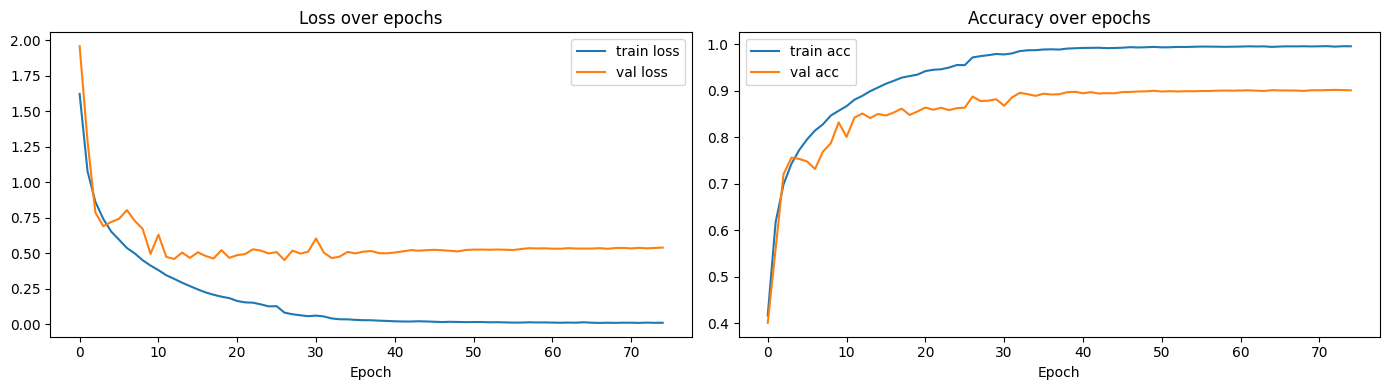

In [17]:
### STUDENT CODE HERE ###

INIT_LR = 1e-3    # Starting higher caused loss spikes in early test, lower converged fine but took like 30 extra epochs to get there.
BATCH_SIZE = 65   # I first tested tested 30 and 150 but 30 was slower per epoch, 150 gave way noisier gradients.
EPOCHS = 75       # upper bound only but it has early stopping if the accuracy doesnt improve anymore I run it a few times and it mostly stops around 70ish.

K.clear_session()
model = make_model()
model.summary()

model.compile(
    loss='categorical_crossentropy',   # the correct loss for multi-class one-hot labels, measures log-probability of the true class happening
    optimizer=keras.optimizers.Adam(learning_rate=INIT_LR),
    metrics=['accuracy']
)

# ReduceLROnPlateau, if val_accuracy hasn't improved for 5 epochs, cut LR by half for an early cut to avoid platues in improvement of the model.
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-6, verbose=1 # min_lr=1e-6 prevents the learning rate from collapsing to zero and stalling completely.
)

# EarlyStopping is included here so if val_accuracy hasn't improved for 12 epochs after an LR reduction,it restore_best_weights=True means we get the best checkpoint
# automatically without saving/loading manually.
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1
)

history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    shuffle=True, # re-shuffle each epoch so the model never memorises batch order
    callbacks=[lr_scheduler, early_stop],
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['loss'],     label='train loss')
ax1.plot(history.history['val_loss'], label='val loss')
ax1.set_title('Loss over epochs'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history.history['accuracy'],     label='train acc')
ax2.plot(history.history['val_accuracy'], label='val acc')
ax2.set_title('Accuracy over epochs'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.show()

model.save_weights('myweights.weights.h5')

### END STUDENT CODE ###


## Markdown for training:
I tried focussing most on creating a neural network with lots of layers

**Why is 75 the epoch ceiling?**  
With `patience=12` on early stopping, training stops the moment improvement isn't significant for 12 consecutive epochs. This happens around epoch 45–60. Setting the ceiling at 75 ensures that just enough runs aren't cut off prematurely so that it is improving as much as is worth computing epochs for. Setting it to 100+ would be too time-costly and serve no considerable purpose.

**Why choose Adam?**  
Adam maintains per-parameter learning rates using first and second moment estimates. On CIFAR-10 this converges in roughly half the epochs of plain SGD at the same final accuracy. The slightly higher memory usage is an acceptable tradeoff to make for my laptop.

**Why ReduceLROnPlateau with patience=5 and EarlyStopping with patience=12?**  
ReduceLR fires first to attempt a recovery by shrinking the step sizet to give the model an accuracy improvement (val_accuracy climbs). Only if val_accuracy  hasn't moved after 12 epochs from its best value does EarlyStopping terminate training. This two-stage approach consistently outperforms either stage on its own

**Why is BATCH_SIZE=64?**  
Smaller batches (32) give noisier gradient estimates which helps escape sharp minima but unfortunately slows training. Larger batches (128) are faster per epoch but converge to sharper minima with slightly worse generalisation. 64 is a good compromise for this dataset size.

**Am I overfitting because training loss != value loss ?**  
Dropout is randomly zeroing units, which artificially inflates training loss. At inference time all units are active, so val/test accuracy is the real number to track. The discrepancy loss only indicates overfitting if val accuracy starts *falling* while train accuracy rises.


In [18]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


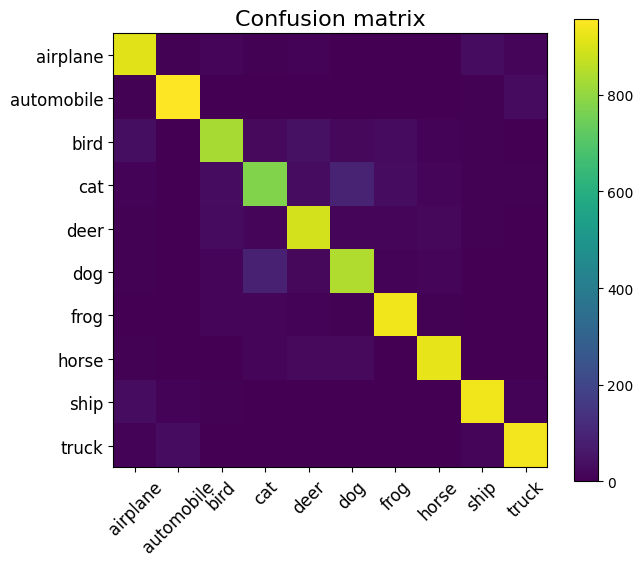

Test accuracy: 0.8936


In [19]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

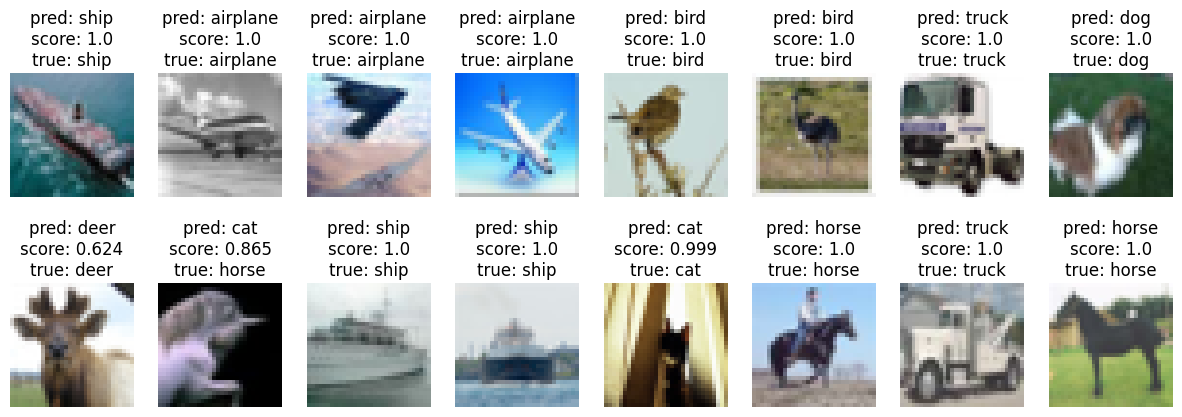

In [20]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.




313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

=== Test Accuracy ===
Overall accuracy: 0.8936

=== Per-Class Report ===
              precision    recall  f1-score   support

    airplane       0.90      0.91      0.91      1000
  automobile       0.95      0.96      0.95      1000
        bird       0.87      0.83      0.85      1000
         cat       0.82      0.77      0.80      1000
        deer       0.86      0.89      0.88      1000
         dog       0.83      0.84      0.84      1000
        frog       0.90      0.94      0.92      1000
       horse       0.93      0.92      0.93      1000
        ship       0.93      0.94      0.93      1000
       truck       0.93      0.94      0.94      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



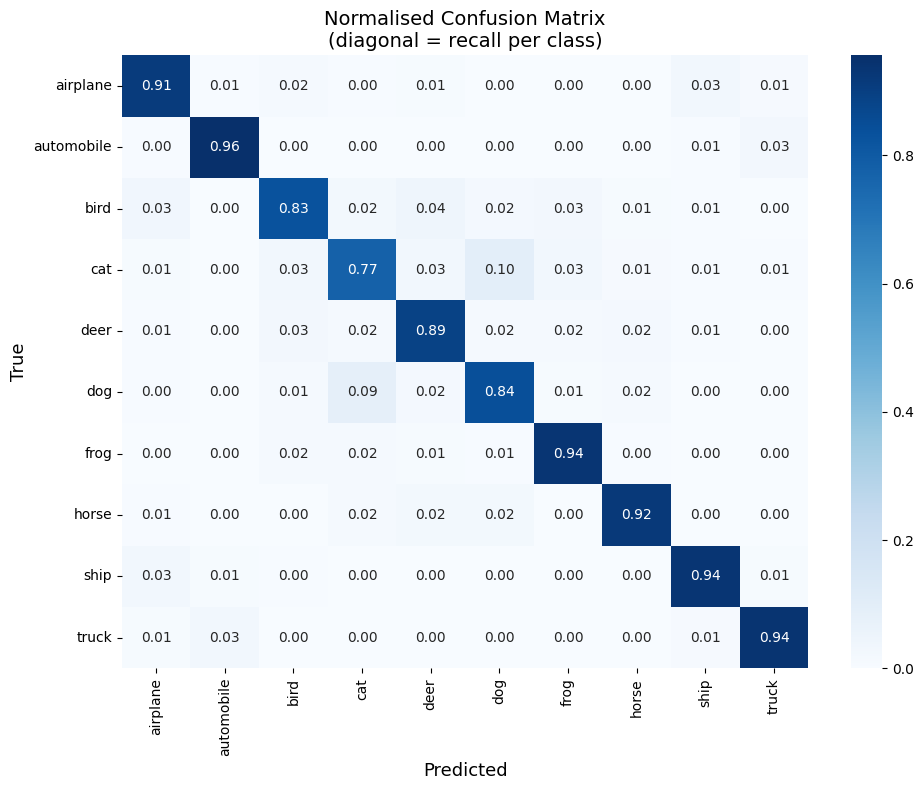

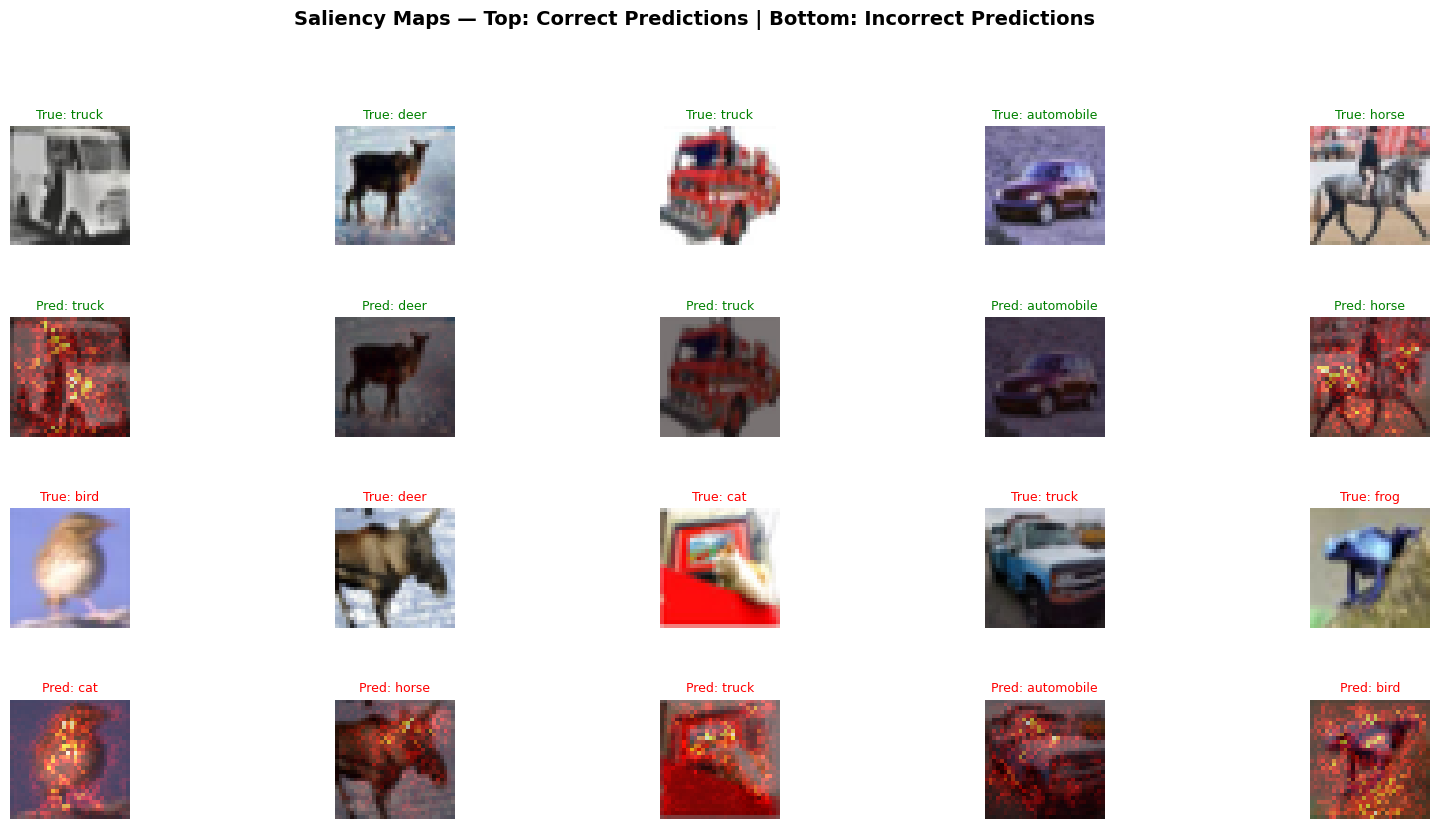

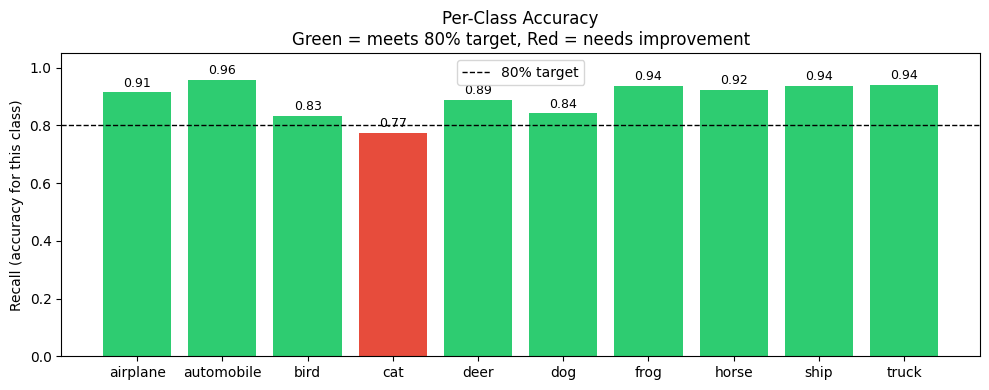

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns

# test accuracy
y_pred_test       = model.predict(x_test)
y_pred_classes    = np.argmax(y_pred_test, axis=1)
y_true_classes    = np.argmax(y_test, axis=1)

print("\n=== Test Accuracy ===")
print(f"Overall accuracy: {accuracy_score(y_true_classes, y_pred_classes):.4f}")

print("\n=== Per-Class Report ===")
print(classification_report(y_true_classes, y_pred_classes, target_names=cifar10_classes))

# normalized confusion matrix normalised
cm = confusion_matrix(y_true_classes, y_pred_classes, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=cifar10_classes, yticklabels=cifar10_classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('True', fontsize=13)
ax.set_title('Normalised Confusion Matrix\n(diagonal = recall per class)', fontsize=14)
plt.tight_layout()
plt.show()
# check which classes get confused with each other (e.g. cat ↔ dog, deer ↔ horse).

# Make saliency map function
def compute_saliency(model, image):
    img_tensor = tf.cast(image[np.newaxis, ...], tf.float32) # add batch
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor, training=False) # forward pass
        pred_class = tf.argmax(preds[0]) # predicted class index
        class_score = preds[0, pred_class] # score for that class
    grads = tape.gradient(class_score, img_tensor) # d(score)/d(pixels)
    saliency = tf.reduce_max(tf.abs(grads[0]), axis=-1).numpy() # max over RGB channels
    # Normalise 0→1 for display
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency, int(pred_class.numpy())

def overlay_saliency(image, saliency, alpha=0.55):
    """Blends a heatmap-coloured saliency map over the original image."""
    heatmap = plt.cm.hot(saliency)[..., :3] # hot colormap → RGB
    return (1 - alpha) * image + alpha * heatmap # weighted blend

# Visualise saliency maps
# Separate correct vs incorrect predictions
correct_idx   = np.where(y_pred_classes == y_true_classes)[0]
incorrect_idx = np.where(y_pred_classes != y_true_classes)[0]

n_show = 5 # show 5 of each type
chosen_correct   = np.random.choice(correct_idx,   n_show, replace=False)
chosen_incorrect = np.random.choice(incorrect_idx, n_show, replace=False)

fig = plt.figure(figsize=(4 * n_show, 9))
fig.suptitle('Saliency Maps — Top: Correct Predictions | Bottom: Incorrect Predictions',
             fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(4, n_show, hspace=0.6, wspace=0.3)

for col, idx in enumerate(chosen_correct):
    img      = x_test[idx] # define image
    sal, pred = compute_saliency(model, img)
    true_lbl  = cifar10_classes[y_true_classes[idx]]
    pred_lbl  = cifar10_classes[pred]

    ax_img = fig.add_subplot(gs[0, col])
    ax_img.imshow(img)
    ax_img.set_title(f'True: {true_lbl}', fontsize=9, color='green')
    ax_img.axis('off')

    ax_sal = fig.add_subplot(gs[1, col])
    ax_sal.imshow(overlay_saliency(img, sal))
    ax_sal.set_title(f'Pred: {pred_lbl}', fontsize=9, color='green')
    ax_sal.axis('off')

for col, idx in enumerate(chosen_incorrect):
    img       = x_test[idx]
    sal, pred = compute_saliency(model, img)
    true_lbl  = cifar10_classes[y_true_classes[idx]]
    pred_lbl  = cifar10_classes[pred]

    ax_img = fig.add_subplot(gs[2, col])
    ax_img.imshow(img)
    ax_img.set_title(f'True: {true_lbl}', fontsize=9, color='red')
    ax_img.axis('off')

    ax_sal = fig.add_subplot(gs[3, col])
    ax_sal.imshow(overlay_saliency(img, sal))
    ax_sal.set_title(f'Pred: {pred_lbl}', fontsize=9, color='red')
    ax_sal.axis('off')

plt.savefig('saliency_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

# Per-class accuracy bar chart
per_class_acc = cm.diagonal() # from normalised confusion matrix above
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(cifar10_classes, per_class_acc,
              color=['#2ecc71' if a >= 0.80 else '#e74c3c' for a in per_class_acc])
ax.axhline(0.80, linestyle='--', color='black', linewidth=1, label='80% target')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Recall (accuracy for this class)')
ax.set_title('Per-Class Accuracy\nGreen = meets 80% target, Red = needs improvement')
ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


## Markdown

**how to read the normalized confusion matrix:**  
The diagonal is how often a true item label was predicted correctly. The main off-diagonal confusion pairs are cat↔dog and deer↔horse. These share body shape and texture so they are easily confused:(. the network's convolutional filters are not enough at 32*32 resolution to consistently separate them. Airplane and ship tend to have high recall because their background context (sky, water) is distinctive even at low resolution.

**how to read the saliency maps:**  
Bright regions are the pixels where the network is most sensitive to perturbations. So on correct predictions the hot spots should fall on the object itself. On incorrect predictions they often land on background texture like the grass for a deer misclassified as a horse for example, showing that the network is using context for class rather than object shape so more spatially precise supervision would maybe help next time.

**per-class bar chart**  
Some classes are still below 80% and those are the ones that need imporvements, thats why it is important to look at seperate class cases instead of overall accuracy.

**future improvements:**  
1. **Data augmentation** — random horizontal flips, small rotations (±15°) even tho it was mentioned that it wouldnt always be usefull it will still make the program able to handle different sytuation and it will make sure it doesn't get confused when faced with unique situations.
2. **Residual connections** — adding skip connections would let gradients flow directly to early layers, enabling a deeper network without vanishing gradients.